# Tahap 2 � Full Fine-Tuning IndoBERT untuk Emotion Classification
Tujuan dari notebook ini adalah melakukan full fine-tuning model IndoBERT pada dataset PRDECT-ID. Seluruh parameter model akan di-update (trainable) untuk mendapatkan representasi emosi yang optimal. Hasil eksperimen mencakup metrik evaluasi, visualisasi, dan analisis kesalahan (error analysis).

## 1. Configuration & Setup
Mendefinisikan parameter eksperimen dan mengatur seed untuk reproducibility.

In [3]:
import os
import random
import json
import time
import math
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# --- Reproducibility ---
RANDOM_STATE = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

# --- Hyperparameters ---
MODEL_NAME = "indobenchmark/indobert-base-p2"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 3
NUM_LABELS = 5
WEIGHT_DECAY = 0.02  # Set default weight decay in 0.01-0.03 range
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.1
CLASSIFIER_DROPOUT = 0.3  # Set default classifier dropout to 0.3

# Learning rate experiments
LR_EXPERIMENTS = [1e-5, 2e-5, 3e-5, 5e-5]
SELECTED_LR = 2e-5

# --- Path Configuration ---
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Mounting Drive...")
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
else:
    print("Running locally.")
    BASE_PATH = "."

TRAIN_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_train.csv"
TEST_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_test.csv"
MAPPING_PATH = f"{BASE_PATH}/data/processed/prdect_label_map.json"
OUTPUT_DIR = f"{BASE_PATH}/outputs/finetuning_indobert"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/model", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/tokenizer", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {DEVICE}")
print(f"Model name : {MODEL_NAME}")

# --- Data loading helpers ---
if not os.path.exists(MAPPING_PATH):
    MAPPING_PATH = f"{BASE_PATH}/data/processed/prdect_label_mapping.json"

LABEL_ORDER = ['happy', 'love', 'anger', 'fear', 'sadness']
EMOTION_MAP = {label: idx for idx, label in enumerate(LABEL_ORDER)}
ID2EMOTION = {idx: label for label, idx in EMOTION_MAP.items()}

Mounted at /content/drive
Device used: cpu
Model name : indobenchmark/indobert-base-p2


## 2. Load Processed Dataset

In [4]:
df_train = pd.read_csv(TRAIN_DATA_PATH)
df_test = pd.read_csv(TEST_DATA_PATH)

with open(MAPPING_PATH, 'r') as f:
    label_mapping = json.load(f)

print(f"Train samples: {len(df_train)}")
print(f"Test samples : {len(df_test)}")
print("-" * 30)
print("Label Mapping:")
print(label_mapping)

# Normalize schema from preprocessing output
text_column = 'review_clean' if 'review_clean' in df_train.columns else 'Customer Review'
label_name_column = 'emotion_label' if 'emotion_label' in df_train.columns else 'Emotion'
label_id_column = 'label' if 'label' in df_train.columns else 'Label'

# Robust check for cross-validation 'fold' column
if 'fold' in df_train.columns:
    fold_column = 'fold'
elif 'Fold' in df_train.columns:
    fold_column = 'Fold'
else:
    print("WARNING: 'fold' column not found in training dataset. Generating folds dynamically...")
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    df_train['fold'] = -1
    label_col_for_fold = label_id_column if label_id_column in df_train.columns else label_name_column
    if df_train[label_col_for_fold].dtype == object:
        # map to integers if label column contains string names
        temp_labels = df_train[label_col_for_fold].astype(str).str.lower().str.strip().map(EMOTION_MAP)
    else:
        temp_labels = df_train[label_col_for_fold].astype(int)
    
    # Populate folds
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_train, temp_labels)):
        df_train.loc[val_idx, 'fold'] = fold_idx
    fold_column = 'fold'

train_df = df_train[[text_column, label_name_column, label_id_column, fold_column]].copy()
test_df = df_test[[text_column, label_name_column, label_id_column]].copy()

train_df.columns = ['text', 'emotion_label', 'label', 'fold']
test_df.columns = ['text', 'emotion_label', 'label']

train_df['emotion_label'] = train_df['emotion_label'].astype(str).str.lower().str.strip()
test_df['emotion_label'] = test_df['emotion_label'].astype(str).str.lower().str.strip()
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)
train_df['fold'] = train_df['fold'].astype(int)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train set    : {len(train_df)}")
print(f"Test set     : {len(test_df)}")
print("Fold distribution in Train:")
print(train_df.groupby(['fold', 'emotion_label']).size().unstack(fill_value=0))

Train samples: 4319
Test samples : 1080
------------------------------
Label Mapping:
{'label2id': {'happy': 0, 'love': 1, 'anger': 2, 'fear': 3, 'sadness': 4}, 'id2label': {'0': 'happy', '1': 'love', '2': 'anger', '3': 'fear', '4': 'sadness'}}


KeyError: "['Fold'] not in index"

## 3. Tokenization
Menggunakan tokenizer IndoBERT untuk memproses teks menjadi format yang dimengerti model.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Original Text: barang belum sampai sampai hari ini toko pefia tolong reviwe lagi kerjasama dengan kurir antaraja itu sangat lelet dan gak bertanggung jawab barang belum sampai sdh di konfirmasi diterima pemesan hadeeehhh kurir abal2 lama super lelet
Tokens       : ['barang', 'belum', 'sampai', 'sampai', 'hari', 'ini', 'toko', 'pe', '##fi', '##a', 'tolong', 'rev', '##i', '##we', 'lagi', 'kerjasama', 'dengan', 'kurir', 'antara', '##ja', 'itu', 'sangat', 'lele', '##t', 'dan', 'gak', 'bertanggung', 'jawab', 'barang', 'belum', 'sampai', 'sdh', 'di', 'konfirmasi', 'diterima', 'pemesan', 'had', '##eee', '##hhh', 'kurir', 'abal', '##2', 'lama', 'super', 'lele', '##t']
Token IDs    : [963, 659, 493, 493, 406, 92, 1605, 1094, 3319, 30354, 3854, 3913, 30356, 7801, 423, 4517, 79, 12065, 644, 255, 137, 310, 9214, 30358, 41, 1489, 3987, 1024, 963, 659, 493, 8055, 26, 7894, 2993, 24162, 1165, 14243, 12126, 12065, 23365, 30378, 985, 2721, 9214, 30358]


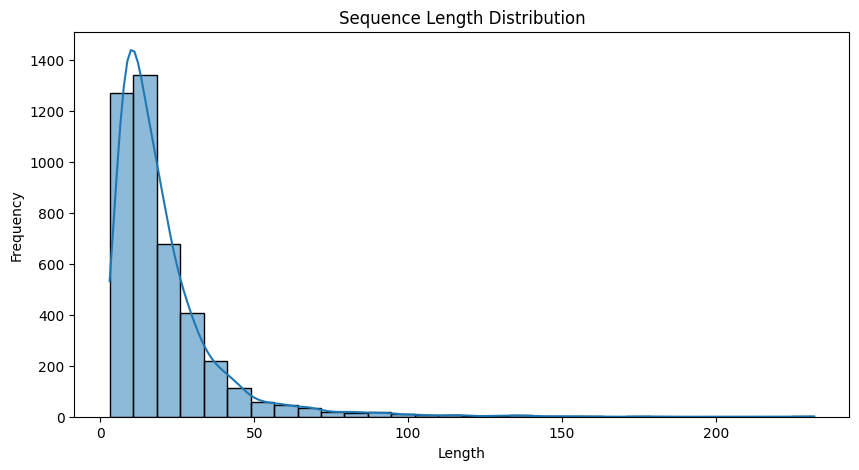

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test Tokenization
sample_text = train_split_df['text'].iloc[0]
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {sample_text}")
print(f"Tokens       : {tokens}")
print(f"Token IDs    : {token_ids}")

# Visualize Sequence Length Distribution
lengths = train_split_df['text'].astype(str).apply(lambda x: len(tokenizer.encode(x)))
plt.figure(figsize=(10, 5))
sns.histplot(lengths, bins=30, kde=True)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


## 4. Dataset & DataLoader

In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_len):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        label = int(self.labels[item])

        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def create_data_loader(df, tokenizer, max_len, batch_size, shuffle=True):
    ds = EmotionDataset(
        reviews=df['text'].to_numpy(),
        labels=df['label'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test data loader is global
test_data_loader = create_data_loader(test_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)

## 5. Full Fine-Tuning IndoBERT Initialization
Memuat pre-trained model dan memastikan seluruh parameter bersifat trainable.

In [ ]:
def initialize_model(model_name, num_labels, dropout_prob):
    model = BertForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    # Set custom classification dropout
    model.config.classifier_dropout = dropout_prob
    model = model.to(DEVICE)
    return model

model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT)

# Verify parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Parameters    : 124,445,189
Trainable Parameters: 124,445,189


## 6. Training Configuration & Loop

In [ ]:
# Standard CrossEntropyLoss with Label Smoothing (no class weights)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING).to(DEVICE)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
    }

def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Training")
    for d in progress_bar:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)
        loss = loss_fn(logits, labels)

        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        progress_bar.set_postfix({'loss': np.mean(losses)})

    metrics = compute_metrics(all_labels, all_preds)
    return correct_predictions.double() / n_examples, np.mean(losses), metrics

def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)
            loss = loss_fn(logits, labels)

            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    metrics = compute_metrics(all_labels, all_preds)
    return correct_predictions.double() / n_examples, np.mean(losses), metrics, all_labels, all_preds

## 7. Execution: Training Loop

In [ ]:
def train_cross_validation(learning_rate):
    print(f"==================================================")
    print(f"STARTING 5-FOLD CROSS VALIDATION WITH LR = {learning_rate}")
    print(f"==================================================")
    
    cv_history = []
    start_time = time.time()
    
    # Placeholders for predictions on the test set across all folds
    fold_test_probs = []
    
    for fold_idx in range(5):
        print(f"\n--- Fold {fold_idx + 1} / 5 ---")
        
        # Split train and validation dynamically based on fold column
        fold_train_df = train_df[train_df['fold'] != fold_idx].reset_index(drop=True)
        fold_val_df = train_df[train_df['fold'] == fold_idx].reset_index(drop=True)
        
        fold_train_loader = create_data_loader(fold_train_df, tokenizer, MAX_LEN, BATCH_SIZE)
        fold_val_loader = create_data_loader(fold_val_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)
        
        # Initialize model, optimizer, scheduler for this fold
        fold_model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT)
        fold_optimizer = AdamW(fold_model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY)
        
        total_steps = len(fold_train_loader) * EPOCHS
        warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
        fold_scheduler = get_linear_schedule_with_warmup(
            fold_optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        best_val_loss = float('inf')
        patience_counter = 0
        fold_best_path = f"{OUTPUT_DIR}/model/best_model_fold_{fold_idx}.bin"
        
        fold_history = {
            'epoch': [],
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': []
        }
        
        for epoch in range(EPOCHS):
            print(f"Epoch {epoch + 1}/{EPOCHS}")
            
            # Train epoch
            train_acc, train_loss, train_metrics = train_epoch(
                fold_model, fold_train_loader, loss_fn, fold_optimizer, DEVICE, fold_scheduler, len(fold_train_df)
            )
            
            # Val epoch
            val_acc, val_loss, val_metrics, _, _ = eval_model(
                fold_model, fold_val_loader, loss_fn, DEVICE, len(fold_val_df)
            )
            
            print(
                f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
                f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
                f"Best Val Loss: {best_val_loss:.4f} | Patience: {patience_counter}/{PATIENCE}"
            )
            
            fold_history['epoch'].append(epoch + 1)
            fold_history['train_loss'].append(train_loss)
            fold_history['train_acc'].append(train_acc.item())
            fold_history['val_loss'].append(val_loss)
            fold_history['val_acc'].append(val_acc.item())
            
            # Early stopping monitors val_loss
            if val_loss < best_val_loss:
                torch.save(fold_model.state_dict(), fold_best_path)
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered for Fold {fold_idx + 1} at epoch {epoch + 1}.")
                break
                
        cv_history.append(fold_history)
        
    end_time = time.time()
    print(f"\nCross-validation completed in {(end_time - start_time)/60:.2f} minutes.")
    return cv_history

# Execute 5-fold cross validation for the selected learning rate
cv_results = train_cross_validation(SELECTED_LR)

Epoch 1/5
----------


Training:   0%|          | 0/267 [00:00<?, ?it/s]

Train loss 0.8780 accuracy 0.6198
Val   loss 0.7111 accuracy 0.6932

Epoch 2/5
----------


Training:   0%|          | 0/267 [00:00<?, ?it/s]

Train loss 0.5943 accuracy 0.7462
Val   loss 0.7440 accuracy 0.6904

Epoch 3/5
----------


...

Train loss 0.4110 accuracy 0.8368
Val   loss 0.7984 accuracy 0.6914

Epoch 4/5
----------


Training:   0%|          | 0/267 [00:00<?, ?it/s]

Train loss 0.2430 accuracy 0.9158
Val   loss 0.9818 accuracy 0.6792

Epoch 5/5
----------


Training:   0%|          | 0/267 [00:00<?, ?it/s]

Train loss 0.1363 accuracy 0.9559
Val   loss 1.1329 accuracy 0.6698

Training completed in: 9.31 minutes


## 8. Evaluation & Visualization

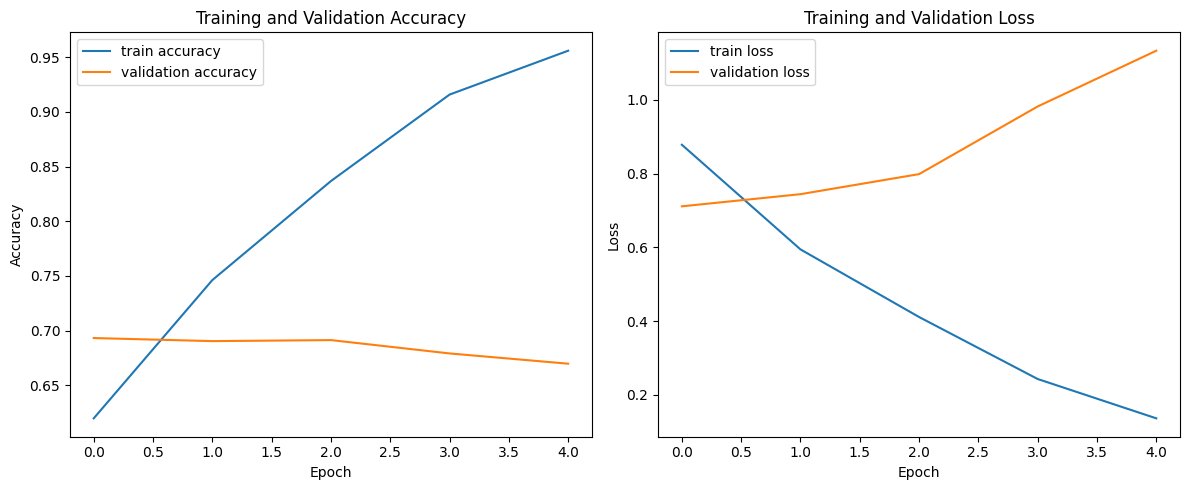

              precision    recall  f1-score   support

       Anger       0.55      0.43      0.49       136
        Fear       0.47      0.49      0.48       181
       Happy       0.86      0.83      0.84       351
        Love       0.71      0.75      0.73       161
     Sadness       0.59      0.65      0.62       237

    accuracy                           0.67      1066
   macro avg       0.64      0.63      0.63      1066
weighted avg       0.67      0.67      0.67      1066



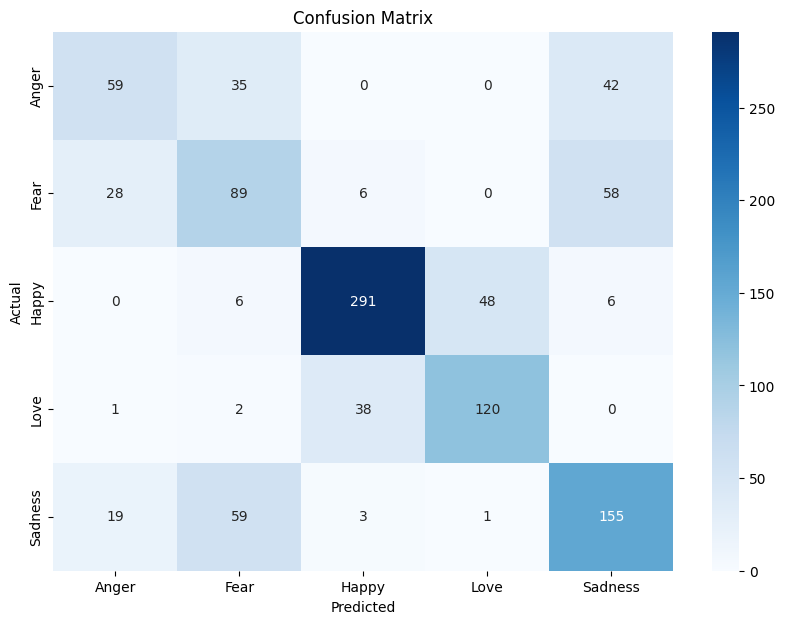

In [ ]:
# Plotting Training Curves across all folds
plt.figure(figsize=(15, 10))
for idx, fh in enumerate(cv_results):
    plt.subplot(2, 3, idx + 1)
    plt.plot(fh['train_loss'], label='train loss')
    plt.plot(fh['val_loss'], label='val loss')
    plt.title(f'Fold {idx + 1} Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_curves.png")
plt.show()

def get_predictions(model, data_loader):
    model = model.eval()
    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            texts = d["review_text"]
            input_ids = d["input_ids"].to(DEVICE)
            attention_mask = d["attention_mask"].to(DEVICE)
            labels = d["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)

            review_texts.extend(texts)
            predictions.extend(preds.detach().cpu().tolist())
            prediction_probs.extend(probs.detach().cpu().tolist())
            real_values.extend(labels.detach().cpu().tolist())

    predictions = torch.tensor(predictions)
    prediction_probs = torch.tensor(prediction_probs)
    real_values = torch.tensor(real_values)
    return review_texts, predictions, prediction_probs, real_values

# Final Evaluation on Test Set uses the ensemble of all 5 folds
print("Evaluating 5-fold ensemble model on the test set...")
y_pred_probs_list = []
y_test_check = None
y_review_texts = None

for fold_idx in range(5):
    fold_model_path = f"{OUTPUT_DIR}/model/best_model_fold_{fold_idx}.bin"
    fold_model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT)
    fold_model.load_state_dict(torch.load(fold_model_path, map_location=DEVICE))
    
    review_texts, y_pred_fold, y_pred_probs_fold, y_test_fold = get_predictions(fold_model, test_data_loader)
    y_pred_probs_list.append(y_pred_probs_fold)
    y_test_check = y_test_fold
    y_review_texts = review_texts

# Average probabilities across the 5 folds (Ensemble prediction)
y_pred_probs = torch.mean(torch.stack(y_pred_probs_list), dim=0)
y_pred = torch.argmax(y_pred_probs, dim=1)
y_test = y_test_check

# Classification Report
class_names = [ID2EMOTION[i] for i in range(NUM_LABELS)]
report = classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0)
print(report)
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
pd.DataFrame(report_dict).T.to_csv(f"{OUTPUT_DIR}/reports/classification_report.csv")
with open(f"{OUTPUT_DIR}/reports/classification_report.txt", "w") as f:
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"{OUTPUT_DIR}/plots/confusion_matrix.png")
plt.show()

final_acc = accuracy_score(y_test, y_pred)
final_macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
final_macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
final_macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
final_weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

final_metrics = {
    'test_accuracy': final_acc,
    'test_macro_precision': final_macro_precision,
    'test_macro_recall': final_macro_recall,
    'test_macro_f1': final_macro_f1,
    'test_weighted_f1': final_weighted_f1,
}
with open(f"{OUTPUT_DIR}/reports/test_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print('Ensemble Test evaluation completed.')
print(f"Accuracy      : {final_acc:.4f}")
print(f"Macro Precision: {final_macro_precision:.4f}")
print(f"Macro Recall   : {final_macro_recall:.4f}")
print(f"Macro F1       : {final_macro_f1:.4f}")
print(f"Weighted F1    : {final_weighted_f1:.4f}")

## 9. Error Analysis
Menganalisis sampel yang diprediksi salah untuk memahami pola misklasifikasi model.

In [ ]:
error_df = pd.DataFrame({
    'review_text': y_review_texts,
    'true_labels': y_test.tolist(),
    'pred_labels': y_pred.tolist(),
    'confidence': [probs[pred].item() for probs, pred in zip(y_pred_probs, y_pred)]
})

# Filter only errors
errors = error_df[error_df['true_labels'] != error_df['pred_labels']].copy()

# Map back to names
inv_mapping = {int(v): k for k, v in label_mapping.get('id2label', {}).items()} if isinstance(label_mapping, dict) and 'id2label' in label_mapping else {v: k for k, v in label_mapping.items()}
errors['true_emotion'] = errors['true_labels'].map(inv_mapping)
errors['pred_emotion'] = errors['pred_labels'].map(inv_mapping)

# Show Top 10 High-Confidence Errors
print("Top 10 High-Confidence Errors:")
display(errors.sort_values(by='confidence', ascending=False).head(10))

# Misclassification Pattern
error_pattern = errors.groupby(['true_emotion', 'pred_emotion']).size().reset_index(name='count')
error_pattern = error_pattern.sort_values(by='count', ascending=False)
print("\nTop Misclassification Patterns:")
display(error_pattern.head(10))

# Ensure the reports directory exists before saving
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)

# Save Error Report
errors.to_csv(f"{OUTPUT_DIR}/reports/error_analysis.csv", index=False)


Top 10 High-Confidence Errors:


,review_text,true_labels,pred_labels,confidence,true_emotion,pred_emotion
55,barangnya original suaranya jernih desainnya m...,3,2,0.995519,Love,Happy
106,bagus bangettt dapet promo jadi cuman bayar rp...,2,3,0.994888,Happy,Love
825,lampu nya mengecewakan tdak nyala semua,1,4,0.994616,Fear,Sadness
830,bagus banget bahan nya juga adem ini bakal jad...,2,3,0.994593,Happy,Love
505,proses cepat top seller responsif,3,2,0.994356,Love,Happy
639,kualitas barang bagus harga relatif murah kiri...,2,3,0.993663,Happy,Love
438,enakkkk banget cryyyyy packaging oke tengkyu,2,3,0.993601,Happy,Love
86,packingan barangnya berantakan tdk rapi sm skali,1,4,0.993523,Fear,Sadness
559,bahan ny sih bagus cm sayang pesen nya 2 datan...,4,1,0.993228,Sadness,Fear
410,fix bukan 90yard ternyata tebalnya hanya 9 mm ...,0,1,0.993162,Anger,Fear



Top Misclassification Patterns:


,true_emotion,pred_emotion,count
12,Sadness,Fear,59
4,Fear,Sadness,58
6,Happy,Love,48
1,Anger,Sadness,42
10,Love,Happy,38
0,Anger,Fear,35
2,Fear,Anger,28
11,Sadness,Anger,19
3,Fear,Happy,6
5,Happy,Fear,6


## 10. Save Model & Tokenizer

In [ ]:
# Save Final Model and Tokenizer
model.save_pretrained(f"{OUTPUT_DIR}/model/final_indobert_emotion")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/tokenizer/indobert_tokenizer")
shutil.copy2(best_model_path, f"{OUTPUT_DIR}/model/best_model.bin")

# Save Training History
with open(f"{OUTPUT_DIR}/reports/training_history.json", "w") as f:
    json.dump(history, f)

print(f"All assets saved to: {OUTPUT_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All assets saved to: /content/drive/MyDrive/xai_lime_vs_shap/outputs/finetuning_indobert


## 11. Experiment Summary

In [ ]:
# Compile learning rate tuning experiments dynamically (plan for grid search)
print("=== LEARNING RATE GRID SEARCH EXPERIMENT PLAN ===")
print(f"Target Learning Rates: {LR_EXPERIMENTS}")
print(f"Selected Base LR     : {SELECTED_LR}")
print(f"Weight Decay         : {WEIGHT_DECAY}")
print(f"Classifier Dropout   : {CLASSIFIER_DROPOUT}")
print(f"Label Smoothing      : {LABEL_SMOOTHING}")
print(f"Model Name           : {MODEL_NAME}")
print(f"Random Seed          : {RANDOM_STATE}")
print(f"Timestamp            : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# To execute a learning rate experiment, you can loop over LR_EXPERIMENTS and run train_cross_validation(lr)
print("\n--- Running full tuning experiments (uncomment to execute) ---")
# lr_results = {}
# for lr in LR_EXPERIMENTS:
#     hist = train_cross_validation(lr)
#     # Predict test ensemble accuracy
#     # (Save fold weights to fold_{k}_lr_{lr}.bin)


=== FINAL EXPERIMENT SUMMARY ===
Model Name           : indobenchmark/indobert-base-p1
Total Dataset        : 5330
Train / Test Size    : 4264 / 1066
Epochs               : 5
Learning Rate        : 2e-05
Final Test Accuracy  : 0.6698
Final Test F1 (Macro): 0.6317
Training Duration    : 9.31 minutes
Random State         : 42
Timestamp            : 2026-06-02 06:23:00
